In [1]:
# Import all functions from the required modules
from cordo_sherpa_module import *
from cordo_chimere_module import *
from expo_functions_module import *
from mortality_chimere_module import *
from cessation_lag_module import *
from association_module import *
from morbidity_chimere_module import *
print("Successfully loaded all modules")

loaded defined RR values
loaded defined RR values
Successfully loaded Cessation Lag functions
Successfully loaded all modules


In [2]:
# Paths to the files
path_fichier_shp = "data/2-output-data/donnees_shp"
title_shp = "donnees_insee_iris"
path_fichier_pourcents = "data/2-output-data"
title_pourcents = "pourcents"

# Load the concentration points
conc_points = coordo_sherpa(sc="s1", pol="ug_NO2", year=2019)

# Load the exported data
donnees_exportees = gpd.read_file(os.path.join(path_fichier_shp, f"{title_shp}.shp"))

# Transform the CRS of the exported data to match the concentration points
donnees_exportees_transformed = donnees_exportees.to_crs(epsg=conc_points.crs.to_epsg())

# Check if CRSs are the same
if conc_points.crs == donnees_exportees_transformed.crs:
    print("CRS for conc_points_transformed and donnees_exportees_transformed are the same.")
else:
    print("CRS for conc_points_transformed and donnees_exportees_transformed are different.")

Concentrations in 2019 and 2019 are calculated for the pollutant 'ug_no2' (s1).
CRS for conc_points_transformed and donnees_exportees_transformed are the same.


In [3]:
import os
# Define paths for shapefiles
path_fichier_shp = "data/2-output-data/donnees_shp"
path_fichier_shp_1 = "data/2-output-data/donnees_shp_1"
path_fichier_shp_2 = "data/2-output-data/donnees_shp_2"
path_fichier_shp_3 = "data/2-output-data/donnees_shp_3"
path_fichier_pourcents = "data/2-output-data"

# Titles for INSEE Data
title_shp = "donnees_insee_iris"
title_shp_1 = "donnees_insee_iris_toutage_1"
title_shp_2 = "donnees_insee_iris_toutage_2"
title_shp_3 = "donnees_insee_iris_toutage_3"
title_pourcents = "pourcents"

# Read shapefiles into GeoDataFrames
donnees_shp_1 = gpd.read_file(os.path.join(path_fichier_shp_1, f"{title_shp_1}.shp"))
donnees_shp_2 = gpd.read_file(os.path.join(path_fichier_shp_2, f"{title_shp_2}.shp"))
donnees_shp_3 = gpd.read_file(os.path.join(path_fichier_shp_3, f"{title_shp_3}.shp"))

# Combine the three GeoDataFrames
donnees_merged = gpd.GeoDataFrame(pd.concat([donnees_shp_1, donnees_shp_2, donnees_shp_3], ignore_index=True))
print(donnees_merged.head())

grille_combinee = gpd.read_file(os.path.join(path_fichier_pourcents, f"{title_pourcents}.shp"))
grille_combinee = grille_combinee.to_crs(conc_points.crs)

     iriscod irisname comcod comname depcod depname  regcod           regname  \
0  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
1  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
2  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
3  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
4  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   

   age    pop2019    pop2030    pop2050  mort2019  mort2030  mort2050  \
0    0  31.979362  30.560224  28.974134  0.114652  0.101665  0.085457   
1    1  32.735555  30.384526  29.200275  0.018369  0.016510  0.014105   
2    2  33.511730  30.265005  29.417218  0.008333  0.007299  0.006310   
3    3  34.431724  30.206960  29.615683  0.005018  0.004605  0.004083   
4    4  35.587474  30.214303  29.787011  0.003853  0.003519  0.003135   

                                            geometry  
0  POLYGON ((497887

In [4]:
#Function to compute the exposure change from the anchor years and pre-defined functions
#Can not be shifted to a module as it relies on the global variables defined in this notebook (e.g. ANCHOR_YEARS,CHIMERE functions etc etc.)
def build_exposure_cache_for_anchors(scenario, pollutant, donnees_exportees_transformed, grille_combinee):
    expo_cache = {}
    for y in ANCHOR_YEARS:
        logging.info(f"[ANCHOR] Computing exposure: Scenario={scenario}, Pollutant={pollutant}, Year={y}")

        conc_points = coordo_chimere(pollutant, year=y, SC=scenario.upper())
        conc_points = conc_points.to_crs(donnees_exportees_transformed.crs)

        conc_chimere = coordo_ineris_chimere(pollutant, year="2019")
        conc_chimere = conc_chimere.to_crs(donnees_exportees_transformed.crs)

        conc_corrige = correction_chimere(conc_points, conc_chimere)
        expo_cache[int(y)] = expo(donnees_exportees_transformed, conc_corrige, grille_combinee)

    return expo_cache

In [ ]:
#Function to run morbidity using above defined functions
import os
import logging
import warnings
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Suppress warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

# Configure logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# Task summary (updated):
# - Compute exposure change using linear interpolation between anchor years
# - Keep exposure constant from 2010..baseline year inclusive (no exposure change)
# - Compute RR change with exposure (per UNIT_CHANGE) for each morbidity endpoint
# - Compute adjusted RR series (3 variants): COMEAP EF, Linear EF, and No-lag EF

# Define scenarios, pollutants, and years
# run one-by-one to avoid memory issues
scenarios = ["s2", "s3"]
pollutants = ["ug_NO2"] #"ug_PM25_RH50", "ug_NO2"
years = list(range(2010, 2070))
ANCHOR_YEARS = [2019, 2030, 2050]


def _validate_anchor_years(anchor_years):
    anchor_years = sorted(set(int(y) for y in anchor_years))
    if len(anchor_years) < 2:
        raise ValueError("Need at least two anchor years to interpolate.")
    return anchor_years

ANCHOR_YEARS = _validate_anchor_years(ANCHOR_YEARS)

# Align CRS of shapefiles
target_crs = donnees_exportees_transformed.crs
donnees_exportees_transformed = donnees_exportees_transformed.to_crs(target_crs)
grille_combinee = grille_combinee.to_crs(target_crs)

# Baseline year for lag + exposure-change anchoring
BASELINE_YEAR = int(globals().get("LAG_BASE_YEAR", 2019))
if BASELINE_YEAR not in years:
    raise ValueError(f"BASELINE_YEAR={BASELINE_YEAR} must be included in `years`.")

# Use mapped RR for morbidity endpoints (assumed RR per 10 ug/m3 unless you change UNIT_CHANGE)
UNIT_CHANGE = 10.0

if "morb_config" not in globals() or morb_config is None:
    raise NameError("morb_config is not defined in the kernel; run the morbidity config cell first.")

years_arr = np.asarray(years, dtype=int)
n_years = int(years_arr.size)
mask_pre = years_arr <= int(BASELINE_YEAR)

plot_rows = []
_frac_cache_by_lag = {}

for scenario in scenarios:
    for pollutant in pollutants:
        rr_key = f"rr_{pollutant}"

        expo_cache = build_exposure_cache_for_anchors(
            scenario, pollutant, donnees_exportees_transformed, grille_combinee
        )
        anchor_means = exposure_mean_from_cache(expo_cache, pollutant)
        expo_linear = interpolate_exposure_means_linear(years_arr, anchor_means)

        base_idx = int(np.where(years_arr == int(BASELINE_YEAR))[0][0])
        base_expo = float(anchor_means.get(int(BASELINE_YEAR), float(expo_linear[base_idx])))

        # Enforce constant exposure for 2010..baseline year inclusive
        expo_linear = np.asarray(expo_linear, dtype=float)
        expo_linear[mask_pre] = float(base_expo)

        delta_exposure = np.asarray(expo_linear, dtype=float) - float(base_expo)

        for ep in morb_config:
            ep_short = ep.get("short", None)
            ep_name = ep.get("disease", ep_short)

            rr_triplet = ep.get(rr_key, None)
            if rr_triplet is None:
                continue

            rr_per_unit, rr_low, rr_high = rr_triplet
            rr_per_unit = float(rr_per_unit)
            rr_low = float(rr_low) if rr_low is not None else np.nan
            rr_high = float(rr_high) if rr_high is not None else np.nan

            lag_years_ep = int(ep.get("lag", 0) if ep.get("lag", 0) is not None else 0)

            # Cache COMEAP + Linear effect fractions per lag
            if lag_years_ep not in _frac_cache_by_lag:
                if lag_years_ep <= 0:
                    frac_comeap_ep = np.ones_like(years_arr, dtype=float)
                    frac_linear_ep = np.ones_like(years_arr, dtype=float)
                else:
                    _, frac_comeap_ep, _, frac_linear_ep = generate_cessation_lag_fractions(
                        base_year=BASELINE_YEAR, eval_years=years_arr, lag_years=lag_years_ep
                    )
                    frac_comeap_ep = np.asarray(frac_comeap_ep, dtype=float)
                    frac_linear_ep = np.asarray(frac_linear_ep, dtype=float)

                # Ensure effect fractions represent "realization after baseline": 0 up to baseline year
                frac_comeap_ep[mask_pre] = 0.0
                frac_linear_ep[mask_pre] = 0.0

                _frac_cache_by_lag[lag_years_ep] = (frac_comeap_ep, frac_linear_ep)

            frac_comeap, frac_linear = _frac_cache_by_lag[lag_years_ep]

            # Absolute RR level at baseline exposure (kept constant before baseline in adjusted RR series)
            rr_base_abs = float(
                rr_from_exposure_change(
                    exposure_year=base_expo,
                    exposure_base=None,
                    rr_per_unit=rr_per_unit,
                    unit_change=UNIT_CHANGE,
                )
            )

            # Absolute RR series from exposure levels (reference only)
            rr_full_linear = rr_from_exposure_change(
                exposure_year=expo_linear,
                exposure_base=None,
                rr_per_unit=rr_per_unit,
                unit_change=UNIT_CHANGE,
            )

            # RR change relative to baseline exposure (RR=1 at baseline)
            rr_change_linear = rr_from_exposure_change(
                exposure_year=expo_linear,
                exposure_base=base_expo,
                rr_per_unit=rr_per_unit,
                unit_change=UNIT_CHANGE,
            )

            # Apply cessation-lag to RR CHANGE (excess risk), then re-anchor to baseline absolute RR
            rr_change_adj_comeap = adjusted_rr_with_cessation_lag(rr_change_linear, frac_comeap)
            rr_change_adj_linear = adjusted_rr_with_cessation_lag(rr_change_linear, frac_linear)

            rr_adj_linear_comeap = rr_base_abs * np.asarray(rr_change_adj_comeap, dtype=float)
            rr_adj_linear_linlag = rr_base_abs * np.asarray(rr_change_adj_linear, dtype=float)

            # RR without any lags (immediate realization of exposure change)
            rr_adj_no_lag = rr_base_abs * np.asarray(rr_change_linear, dtype=float)

            for idx, y in enumerate(years_arr):
                plot_rows.append(
                    {
                        "scenario": scenario,
                        "pollutant": pollutant,
                        "endpoint_short": ep_short,
                        "endpoint": ep_name,
                        "year": int(y),
                        "baseline_year": int(BASELINE_YEAR),
                        "baseline_exposure_mean": float(base_expo),
                        "rr_per_unit": float(rr_per_unit),
                        "rr_low": float(rr_low),
                        "rr_high": float(rr_high),
                        "unit_change": float(UNIT_CHANGE),
                        "lag_years": int(lag_years_ep),
                        "exposure_mean_linear": float(expo_linear[idx]),
                        "delta_exposure_linear": float(delta_exposure[idx]),
                        "rr_full_linear": float(rr_full_linear[idx]),
                        "rr_change_linear_no_lag": float(rr_change_linear[idx]),
                        "rr_adj_no_lag": float(rr_adj_no_lag[idx]),
                        "frac_comeap": float(frac_comeap[idx]),
                        "frac_linear": float(frac_linear[idx]),
                        "rr_adj_linear_comeap": float(rr_adj_linear_comeap[idx]),
                        "rr_adj_linear_linlag": float(rr_adj_linear_linlag[idx]),
                    }
                )

rr_plot_df = pd.DataFrame(plot_rows)

INFO:root:[ANCHOR] Computing exposure: Scenario=s2, Pollutant=ug_NO2, Year=2019


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_ineris function


INFO:root:Starting optimized expo function


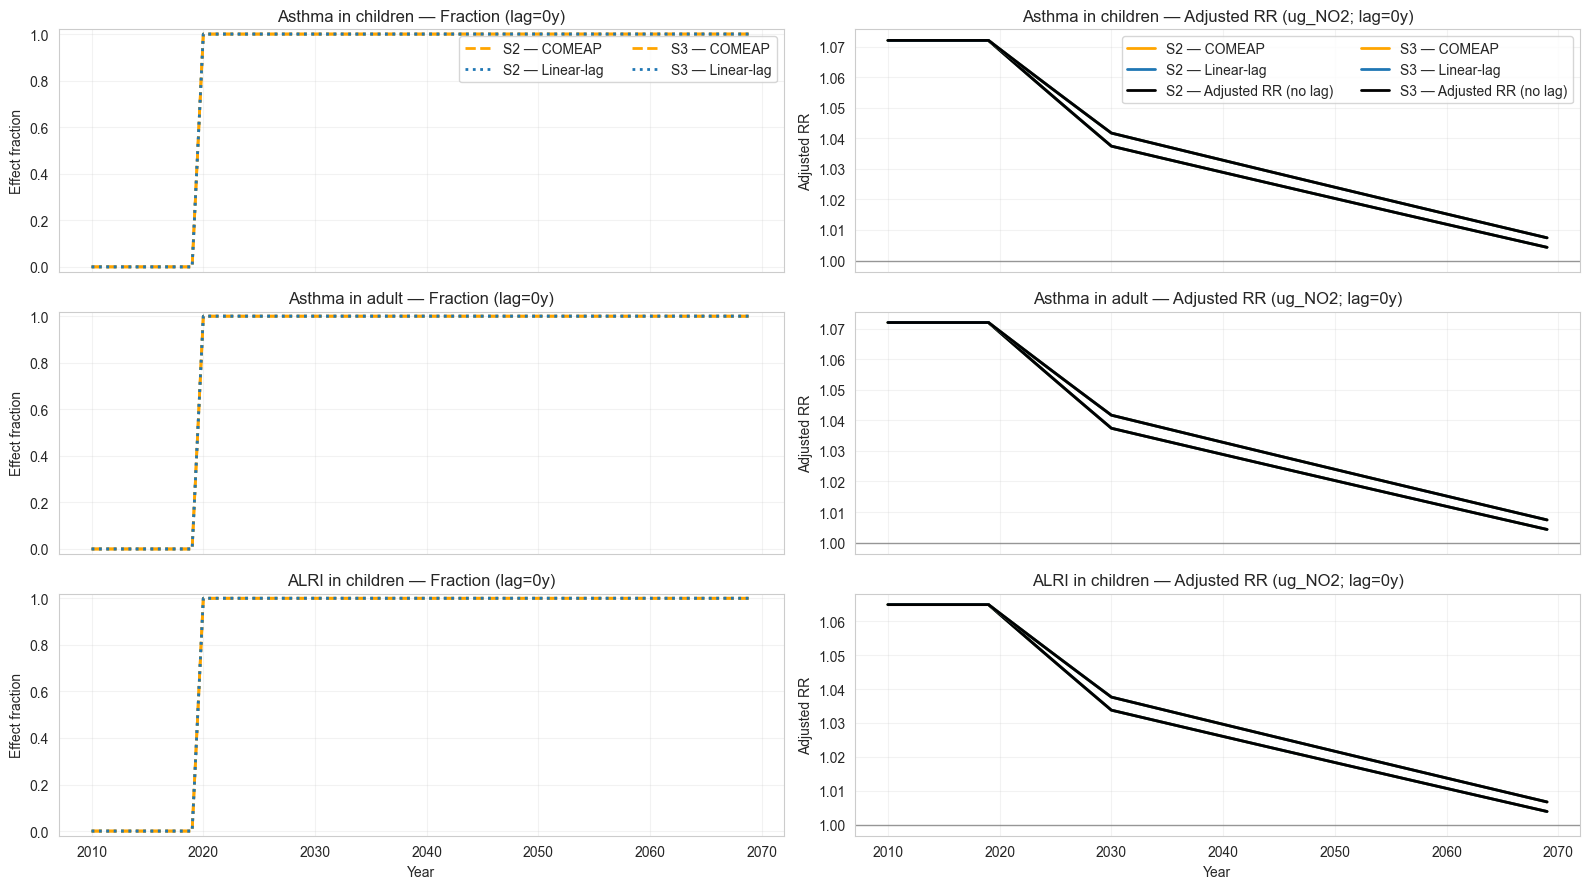

In [10]:
# Task: Plot cessation-lag weights (effect fractions) and adjusted RR over time for each morbidity endpoint,
#       arranged as a matrix with diseases in rows and [fractions, adjusted RR] side-by-side columns.
#       Update styling: COMEAP in orange; reference fractions not shown in black.

# --- Ensure columns used for plotting exist in rr_plot_df ---
if "delta_c_year_linear" not in rr_plot_df.columns:
    if "baseline_exposure_mean" in rr_plot_df.columns and "exposure_mean_linear" in rr_plot_df.columns:
        rr_plot_df = rr_plot_df.copy()
        rr_plot_df["delta_c_year_linear"] = (
                rr_plot_df["exposure_mean_linear"].astype(float) - rr_plot_df["baseline_exposure_mean"].astype(float)
        )
    elif "exposure_mean_linear" in rr_plot_df.columns:
        rr_plot_df = rr_plot_df.copy()
        _base = (
            rr_plot_df.loc[rr_plot_df["year"].astype(int) == int(BASELINE_YEAR)]
            .groupby(["scenario", "pollutant"])["exposure_mean_linear"]
            .mean()
        )
        rr_plot_df["delta_c_year_linear"] = rr_plot_df.apply(
            lambda r: float(r["exposure_mean_linear"]) - float(_base.loc[(r["scenario"], r["pollutant"])]),
            axis=1,
        )

_required_plot_cols = [
    "scenario",
    "pollutant",
    "year",
    "frac_comeap",
    "frac_linear",
    "rr_adj_linear_comeap",
    "rr_adj_linear_linlag",
    "rr_change_linear_no_lag",
    "rr_adj_no_lag",
    "endpoint_short",
    "endpoint",
]
_missing_plot_cols = [c for c in _required_plot_cols if c not in rr_plot_df.columns]
if _missing_plot_cols:
    raise KeyError(
        "Plotting column(s) missing from rr_plot_df: "
        f"{_missing_plot_cols}\nAvailable columns: {list(rr_plot_df.columns)}"
    )

scenario_list = scenarios if "scenarios" in globals() and len(scenarios) else rr_plot_df["scenario"].unique().tolist()
pollutant_to_plot = pollutants[0] if "pollutants" in globals() and len(pollutants) else rr_plot_df["pollutant"].iloc[0]

sub_all = rr_plot_df[rr_plot_df["pollutant"] == pollutant_to_plot].copy()
if sub_all.empty:
    raise ValueError(f"No rows found in rr_plot_df for pollutant={pollutant_to_plot}")

# Prefer endpoint_short ordering by morb_config if available; else alphabetical
if "morb_config" in globals() and morb_config is not None:
    _order = [ep.get("short") for ep in morb_config if ep.get("short") is not None]
    endpoint_shorts = [s for s in _order if s in set(sub_all["endpoint_short"].dropna().astype(str))]
    if not endpoint_shorts:
        endpoint_shorts = sorted(sub_all["endpoint_short"].dropna().astype(str).unique().tolist())
else:
    endpoint_shorts = sorted(sub_all["endpoint_short"].dropna().astype(str).unique().tolist())

endpoint_label_map = (
    sub_all.dropna(subset=["endpoint_short", "endpoint"])
    .drop_duplicates(subset=["endpoint_short"])
    .set_index("endpoint_short")["endpoint"]
    .to_dict()
)


# --- Reference cessation-lag fractions (30/50/20) ---
def _calculate_delay_weights_30y(first_year_share=0.30, years_2_5_share=0.50, years_6_20_share=0.20):
    w = np.zeros(30, dtype=float)
    w[0] = float(first_year_share)
    w[1:5] = float(years_2_5_share) / 4.0
    w[5:20] = float(years_6_20_share) / 15.0
    s = w.sum()
    return w / s if s > 0 else w

def _cumulative_effect_fraction(eval_years, base_year, delay_weights):
    eval_years = np.asarray(eval_years, dtype=int)
    L = len(delay_weights)
    out = np.zeros_like(eval_years, dtype=float)
    for i, y in enumerate(eval_years):
        d = y - int(base_year)
        if d < 0:
            out[i] = 0.0
        else:
            out[i] = float(np.asarray(delay_weights, dtype=float)[: min(L, d + 1)].sum())
    return out
_years_ref = np.sort(sub_all["year"].dropna().astype(int).unique())
_ref_delay_w = _calculate_delay_weights_30y(
    first_year_share=0.30, years_2_5_share=0.50, years_6_20_share=0.20
)
_ref_frac = _cumulative_effect_fraction(_years_ref, BASELINE_YEAR, _ref_delay_w)

# Styling
COMEAP_COLOR = "orange"
LINEAR_COLOR = "#1f77b4"  # matplotlib default blue
REF_COLOR = "#7f7f7f"  # not black

# ----------------------------
# SINGLE FIGURE: Matrix (rows=endpoints, cols=[fractions, adjusted RR])
# ----------------------------
n_endpoints = len(endpoint_shorts)
nrows = max(1, n_endpoints)
ncols = 2

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, max(3.0 * nrows, 5.0)),
    sharex=True,
    squeeze=False,
)

for r, ep_short in enumerate(endpoint_shorts):
    ep_name = endpoint_label_map.get(ep_short, ep_short)

    ax_frac = axes[r, 0]
    ax_rr = axes[r, 1]

    ep_df = sub_all[sub_all["endpoint_short"].astype(str) == str(ep_short)].copy()
    if ep_df.empty:
        ax_frac.set_visible(False)
        ax_rr.set_visible(False)
        continue

    _lag_years_ep = int(
        pd.to_numeric(ep_df["lag_years"], errors="coerce").dropna().iloc[0]
    ) if "lag_years" in ep_df.columns and ep_df["lag_years"].notna().any() else 0

    for scenario in scenario_list:
        sub = ep_df[ep_df["scenario"] == scenario].sort_values("year").copy()
        if sub.empty:
            continue

        # Fractions
        ax_frac.plot(
            sub["year"],
            sub["frac_comeap"],
            color=COMEAP_COLOR,
            linewidth=2,
            linestyle="--",
            label=f"{scenario.upper()} — COMEAP",
        )
        ax_frac.plot(
            sub["year"],
            sub["frac_linear"],
            color=LINEAR_COLOR,
            linewidth=2,
            linestyle=":",
            label=f"{scenario.upper()} — Linear-lag",
        )

        # Adjusted RR
        ax_rr.plot(
            sub["year"],
            sub["rr_adj_linear_comeap"],
            color=COMEAP_COLOR,
            linewidth=2,
            linestyle="-",
            label=f"{scenario.upper()} — COMEAP",
        )
        ax_rr.plot(
            sub["year"],
            sub["rr_adj_linear_linlag"],
            color=LINEAR_COLOR,
            linewidth=2,
            linestyle="-",
            label=f"{scenario.upper()} — Linear-lag",
        )
        ax_rr.plot(
            sub["year"],
            sub["rr_adj_no_lag"],
            color="black",
            linewidth=2,
            linestyle="-",
            label=f"{scenario.upper()} — Adjusted RR (no lag)",
        )

    ax_frac.set_title(f"{ep_name} — Fraction (lag={_lag_years_ep}y)")
    ax_frac.set_ylabel("Effect fraction")
    ax_frac.set_ylim(-0.02, 1.02)
    ax_frac.grid(True, alpha=0.25)

    ax_rr.axhline(1.0, color=REF_COLOR, linewidth=1, alpha=0.8)
    ax_rr.set_title(f"{ep_name} — Adjusted RR ({pollutant_to_plot}; lag={_lag_years_ep}y)")
    ax_rr.set_ylabel("Adjusted RR")
    ax_rr.grid(True, alpha=0.25)

    if r == 0:
        ax_frac.legend(loc="best", ncol=2)
        ax_rr.legend(loc="best", ncol=2)

axes[-1, 0].set_xlabel("Year")
axes[-1, 1].set_xlabel("Year")
plt.tight_layout()
plt.show()


In [11]:
# --- Export: morbidity runs by disease + avoided-risk multipliers (2019-2070) ---
# - For each (scenario, pollutant, disease/endpoint_short, year), compute avoided-risk multipliers:
#     annual multiplier = avoided_lag / avoided_no_lag
#     cumulative multiplier = cumulative avoided_lag / cumulative avoided_no_lag
#   where avoided = (baseline RR - scenario RR), baseline RR is the first year in-series (typically 2019)
# - Export full morbidity table to Excel AND multipliers table to CSV.

_export_start = 2019
_export_end = 2070

export_cols = [
    "scenario",
    "pollutant",
    "endpoint_short",
    "endpoint",
    "year",
    "baseline_exposure_mean",
    "lag_years",
    "exposure_mean_linear",
    "delta_exposure_linear",
    "rr_adj_no_lag",
    "frac_comeap",
    "frac_linear",
    "rr_adj_linear_comeap",
    "rr_adj_linear_linlag",
]

if "rr_plot_df" not in globals() or rr_plot_df is None or len(rr_plot_df) == 0:
    raise NameError("rr_plot_df is not defined or is empty; run morbidity RR generation first.")

_rr_export_all = rr_plot_df.copy()

for _need in ["endpoint_short", "endpoint"]:
    if _need not in _rr_export_all.columns:
        _rr_export_all[_need] = np.nan

# Compare against mortality CSV storage ("mort_file") columns, and add any missing columns to morbidity export
_mort_cols = []
try:
    _mort_base_path = r"data/2-output-data"
    if os.path.isdir(_mort_base_path):
        _mort_candidates = [
            os.path.join(_mort_base_path, f)
            for f in os.listdir(_mort_base_path)
            if f.lower().endswith(".csv") and f.lower().startswith("exposure_changes_multipliers_")
        ]
        if _mort_candidates:
            _mort_file = max(_mort_candidates, key=os.path.getmtime)
            _mort_cols = list(pd.read_csv(_mort_file, nrows=0).columns)
except Exception:
    _mort_cols = []

for c in _mort_cols:
    if c not in export_cols:
        export_cols.append(c)

_rr_export_all["year"] = pd.to_numeric(_rr_export_all["year"], errors="coerce").astype("Int64")
_rr_export_all = _rr_export_all.dropna(subset=["year"]).copy()
_rr_export_all["year"] = _rr_export_all["year"].astype(int)

_rr_export_all = _rr_export_all[_rr_export_all["year"].between(_export_start, _export_end)].copy()
_rr_export_all = _rr_export_all.sort_values(["scenario", "pollutant", "endpoint_short", "year"]).copy()

for c in export_cols:
    if c not in _rr_export_all.columns:
        _rr_export_all[c] = np.nan
_rr_export_all = _rr_export_all[export_cols].copy()

# ----------------------------
# Compute avoided-risk multipliers per (scenario, pollutant, endpoint_short)
# ----------------------------
_rr_mult = _rr_export_all.copy()

# Ensure delta_c_year_linear exists for export compatibility with other workflows
if "delta_c_year_linear" not in _rr_mult.columns:
    if "delta_exposure_linear" in _rr_mult.columns:
        _rr_mult["delta_c_year_linear"] = pd.to_numeric(_rr_mult["delta_exposure_linear"], errors="coerce")
    elif "baseline_exposure_mean" in _rr_mult.columns and "exposure_mean_linear" in _rr_mult.columns:
        _rr_mult["delta_c_year_linear"] = (
                pd.to_numeric(_rr_mult["exposure_mean_linear"], errors="coerce")
                - pd.to_numeric(_rr_mult["baseline_exposure_mean"], errors="coerce")
        )
    else:
        _rr_mult["delta_c_year_linear"] = np.nan

for _c in ["rr_adj_no_lag", "rr_adj_linear_comeap"]:
    if _c in _rr_mult.columns:
        _rr_mult[_c] = pd.to_numeric(_rr_mult[_c], errors="coerce")

_mult_out = []
_group_cols = ["scenario", "pollutant", "endpoint_short", "endpoint"]
for _keys, _g in _rr_mult.groupby(_group_cols, dropna=False, sort=False):
    _g = _g.sort_values("year").copy()

    rr_no_lag = _g["rr_adj_no_lag"].to_numpy(dtype=float)
    rr_lag = _g["rr_adj_linear_comeap"].to_numpy(dtype=float)

    _valid = np.isfinite(rr_no_lag)
    rr_baseline = float(rr_no_lag[np.argmax(_valid)]) if _valid.any() else np.nan

    avoided_no_lag = rr_baseline - rr_no_lag
    avoided_lag = rr_baseline - rr_lag

    avoided_no_lag = np.where(np.isfinite(avoided_no_lag), np.maximum(avoided_no_lag, 0.0), np.nan)
    avoided_lag = np.where(np.isfinite(avoided_lag), np.maximum(avoided_lag, 0.0), np.nan)

    annual_multiplier = np.where(
        (avoided_no_lag > 0.0) & np.isfinite(avoided_no_lag) & np.isfinite(avoided_lag),
        avoided_lag / avoided_no_lag,
        np.nan,
    )

    _avoided_no_lag_for_cum = np.where(np.isfinite(avoided_no_lag), avoided_no_lag, 0.0)
    _avoided_lag_for_cum = np.where(np.isfinite(avoided_lag), avoided_lag, 0.0)

    cum_avoided_no_lag = np.cumsum(_avoided_no_lag_for_cum)
    cum_avoided_lag = np.cumsum(_avoided_lag_for_cum)

    cumulative_multiplier = np.where(
        cum_avoided_no_lag > 0.0,
        cum_avoided_lag / cum_avoided_no_lag,
        np.nan,
    )

    _g["rr_baseline"] = rr_baseline
    _g["avoided_no_lag"] = avoided_no_lag
    _g["avoided_lag_comeap"] = avoided_lag
    _g["annual_multiplier_lag_over_no_lag"] = annual_multiplier
    _g["cumulative_avoided_no_lag"] = cum_avoided_no_lag
    _g["cumulative_avoided_lag_comeap"] = cum_avoided_lag
    _g["cumulative_multiplier_lag_over_no_lag"] = cumulative_multiplier

    _mult_out.append(_g)

multipliers_df = pd.concat(_mult_out, ignore_index=True) if _mult_out else pd.DataFrame()

# ----------------------------
# Exports
# ----------------------------
base_path = r"data\2-output-data"
os.makedirs(base_path, exist_ok=True)

_scen_tag = str(scenarios[0]) if "scenarios" in globals() and len(scenarios) else "scenario"
_pol_tag = str(pollutants[0]) if "pollutants" in globals() and len(pollutants) else "pollutant"

excel_path = os.path.join(
    base_path,
    f"morbidity_exposure_changes_multipliers_{_scen_tag}_{_pol_tag}_{_export_start}_{_export_end}.xlsx",
)
_rr_export_all.to_excel(excel_path, index=False, sheet_name="morbidity_all")

# Multipliers CSV (all diseases/scenarios/years; compatible columns + multiplier fields)
_lag_base_path = os.path.join("data", "2-output-data", "Cessation_lags")
os.makedirs(_lag_base_path, exist_ok=True)

_multipliers_export_cols = [
    "scenario",
    "pollutant",
    "endpoint_short",
    "endpoint",
    "year",
    "exposure_mean_linear",
    "delta_c_year_linear",
    "rr_adj_no_lag",
    "rr_adj_linear_comeap",
    "rr_baseline",
    "avoided_no_lag",
    "avoided_lag_comeap",
    "annual_multiplier_lag_over_no_lag",
    "cumulative_avoided_no_lag",
    "cumulative_avoided_lag_comeap",
    "cumulative_multiplier_lag_over_no_lag",
]
for c in _multipliers_export_cols:
    if c not in multipliers_df.columns:
        multipliers_df[c] = np.nan
multipliers_df = multipliers_df[_multipliers_export_cols].copy()

out_csv = f"morbidity_multiplier_lag_v_no_lag_AVOIDED__ALL_{_export_start}_{_export_end}.csv"
out_csv_path = os.path.join(_lag_base_path, out_csv)
multipliers_df.to_csv(out_csv_path, index=False)

print(f"Saved morbidity Excel: {excel_path}")
print(f"Saved morbidity multipliers CSV: {out_csv_path}")


Saved morbidity Excel: data\2-output-data\morbidity_exposure_changes_multipliers_s2_ug_NO2_2019_2070.xlsx
Saved morbidity multipliers CSV: data\2-output-data\Cessation_lags\morbidity_multiplier_lag_v_no_lag_AVOIDED__ALL_2019_2070.csv


C:\Users\aysharma\AppData\Local\Temp\ipykernel_16976\1868555429.py:109: RuntimeWarning: invalid value encountered in divide
  avoided_lag / avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel_16976\1868555429.py:121: RuntimeWarning: invalid value encountered in divide
  cum_avoided_lag / cum_avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel_16976\1868555429.py:109: RuntimeWarning: invalid value encountered in divide
  avoided_lag / avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel_16976\1868555429.py:121: RuntimeWarning: invalid value encountered in divide
  cum_avoided_lag / cum_avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel_16976\1868555429.py:109: RuntimeWarning: invalid value encountered in divide
  avoided_lag / avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel_16976\1868555429.py:121: RuntimeWarning: invalid value encountered in divide
  cum_avoided_lag / cum_avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipy

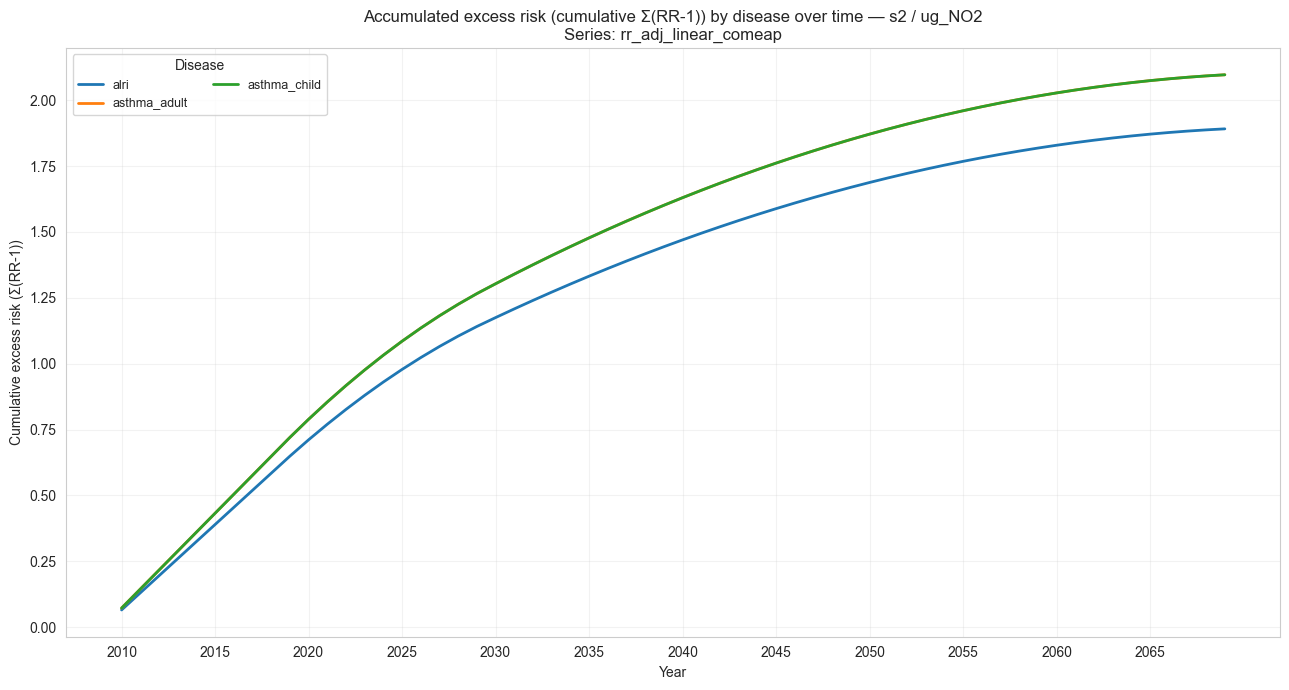

In [12]:
# Visualise accumulated risk per disease as a line plot (cumulative excess risk over years)
import matplotlib.pyplot as plt

# --- Validate input ---
if "rr_plot_df" not in globals() or rr_plot_df is None or len(rr_plot_df) == 0:
    raise NameError("rr_plot_df is not defined or is empty; run the RR generation cell first.")

_rr = rr_plot_df.copy()

_rr_required_base = ["year"]
_missing = [c for c in _rr_required_base if c not in _rr.columns]
if _missing:
    raise KeyError(f"Required column(s) missing from rr_plot_df: {_missing}")

_rr["year"] = pd.to_numeric(_rr["year"], errors="coerce").astype("Int64")
_rr = _rr.dropna(subset=["year"]).copy()
_rr["year"] = _rr["year"].astype(int)

# Prefer these adjusted RR columns if present
_rr_candidates = [
    "rr_adj_linear_comeap",
    "rr_adj_linear_linlag",
    "rr_adj_no_lag",
]
_rr_cols = [c for c in _rr_candidates if c in _rr.columns]
if not _rr_cols:
    raise KeyError(
        "No adjusted RR columns found in rr_plot_df. Expected one of: "
        f"{_rr_candidates}\nAvailable columns: {list(_rr.columns)}"
    )

# Grouping dimensions available in rr_plot_df (ensure endpoint is included for per-disease)
_group_cols = [c for c in ["scenario", "pollutant", "endpoint_short", "endpoint", "lag_years"] if c in _rr.columns]
if not any(c in _group_cols for c in ["endpoint_short", "endpoint"]):
    raise KeyError(
        "No endpoint column found in rr_plot_df to plot per-disease lines. "
        "Expected 'endpoint_short' and/or 'endpoint'."
    )

# Coerce RR columns to numeric
for c in _rr_cols:
    _rr[c] = pd.to_numeric(_rr[c], errors="coerce")
_rr = _rr.dropna(subset=_rr_cols).copy()
if _rr.empty:
    raise ValueError("rr_plot_df has no usable numeric adjusted RR values after cleaning.")

# --- Accumulate EXCESS risk over years (per group): cumulative sum of (RR-1) ---
_out_rows = []
for keys, g in _rr.groupby(_group_cols, dropna=False, sort=False):
    g = g.sort_values("year").copy()

    for rr_col in _rr_cols:
        rr_vals = g[rr_col].to_numpy(dtype=float)
        rr_vals = np.where(np.isfinite(rr_vals), rr_vals, np.nan)

        annual_excess = rr_vals - 1.0
        annual_excess = np.where(np.isfinite(annual_excess), annual_excess, 0.0)

        cumulative_excess = np.cumsum(annual_excess)

        row_dict = dict(zip(_group_cols, keys if isinstance(keys, tuple) else (keys,)))
        _out_rows.append(
            pd.DataFrame(
                {
                    **{k: np.full(g.shape[0], v, dtype=object) for k, v in row_dict.items()},
                    "year": g["year"].to_numpy(dtype=int, copy=False),
                    "rr_series": np.full(g.shape[0], rr_col, dtype=object),
                    "rr_adj": rr_vals.astype(float, copy=False),
                    "annual_excess": annual_excess.astype(float, copy=False),
                    "cumulative_excess": cumulative_excess.astype(float, copy=False),
                }
            )
        )

risk_accum_df = pd.concat(_out_rows, ignore_index=True) if _out_rows else pd.DataFrame()
if risk_accum_df.empty:
    raise ValueError("Failed to build accumulated-risk dataframe (risk_accum_df is empty).")

# --- Build per-disease line-plot data (single scenario/pollutant; single RR series) ---
_plot_df = risk_accum_df.copy()

# Choose first available combination (consistent with earlier cells)
if "scenario" in _plot_df.columns and "scenarios" in globals() and len(scenarios):
    _plot_df = _plot_df[_plot_df["scenario"] == scenarios[0]]
if "pollutant" in _plot_df.columns and "pollutants" in globals() and len(pollutants):
    _plot_df = _plot_df[_plot_df["pollutant"] == pollutants[0]]

# Prefer COMEAP adjusted RR for plot if present, else first available
_rr_series_to_plot = "rr_adj_linear_comeap" if "rr_adj_linear_comeap" in _rr_cols else _rr_cols[0]
_plot_df = _plot_df[_plot_df["rr_series"] == _rr_series_to_plot].copy()

# Pick endpoint identifier for lines
_row_id = "endpoint_short" if "endpoint_short" in _plot_df.columns else "endpoint"

_plot_df[_row_id] = _plot_df[_row_id].astype(str)
_plot_df = _plot_df.dropna(subset=["year", _row_id, "cumulative_excess"]).copy()
if _plot_df.empty:
    raise ValueError("No data available to plot after filtering.")

# Pivot for plotting: index=year, columns=diseases, values=cumulative excess (Σ(RR-1))
line_pivot = (
    _plot_df.pivot_table(
        index="year",
        columns=_row_id,
        values="cumulative_excess",
        aggfunc="mean",
    )
    .sort_index()
)

if line_pivot.empty:
    raise ValueError("No data available to plot after pivot.")

# --- Plot (single figure) ---
fig, ax = plt.subplots(figsize=(13, 7))

for disease in line_pivot.columns.tolist():
    y = pd.to_numeric(line_pivot[disease], errors="coerce").to_numpy(dtype=float)
    if not np.isfinite(y).any():
        continue
    ax.plot(line_pivot.index.to_numpy(dtype=int), y, linewidth=2, label=str(disease))

_title_parts = []
if "scenario" in _plot_df.columns and _plot_df["scenario"].notna().any():
    _title_parts.append(str(_plot_df["scenario"].dropna().iloc[0]))
if "pollutant" in _plot_df.columns and _plot_df["pollutant"].notna().any():
    _title_parts.append(str(_plot_df["pollutant"].dropna().iloc[0]))

ax.set_title(
    "Accumulated excess risk (cumulative Σ(RR-1)) by disease over time"
    + (f" — {' / '.join(_title_parts)}" if _title_parts else "")
    + f"\nSeries: {_rr_series_to_plot}"
)
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative excess risk (Σ(RR-1))")
ax.grid(True, alpha=0.25)

years_sorted = line_pivot.index.to_numpy(dtype=int)
if years_sorted.size:
    xt = years_sorted[::5] if years_sorted.size > 10 else years_sorted
    ax.set_xticks(xt)

ax.legend(title="Disease", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
